<a href="https://colab.research.google.com/github/Ad66-a/transport/blob/main/DHS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 8.7 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


DATA LOADING SUMMARY
Dataset shape: (10783, 1324)

First 5 rows:
            caseid  bidx v000  v001  v002  v003  v004     v005  v006  v007  \
0         1   9  2     1  TZ8     1     9     2     1  1409657     4  2022   
1         1  16  1     1  TZ8     1    16     1     1  1409657     4  2022   
2         1  30  2     1  TZ8     1    30     2     1  1409657     4  2022   
3         1  41  2     1  TZ8     1    41     2     1  1409657     4  2022   
4         1  41  2     2  TZ8     1    41     2     1  1409657     4  2022   

   ...  s631as  s631at  s631au  s631av  s631aw  s631ax  s631ay  s631az  s633b  \
0  ...     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN    NaN   
1  ...     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN    NaN   
2  ...     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN    NaN   
3  ...     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN    NaN   
4  ...     NaN     NaN     NaN     NaN     NaN     NaN     Na

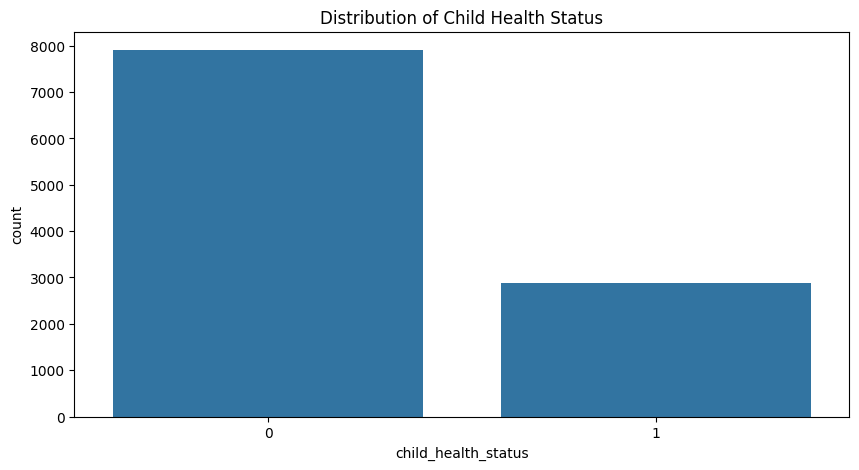

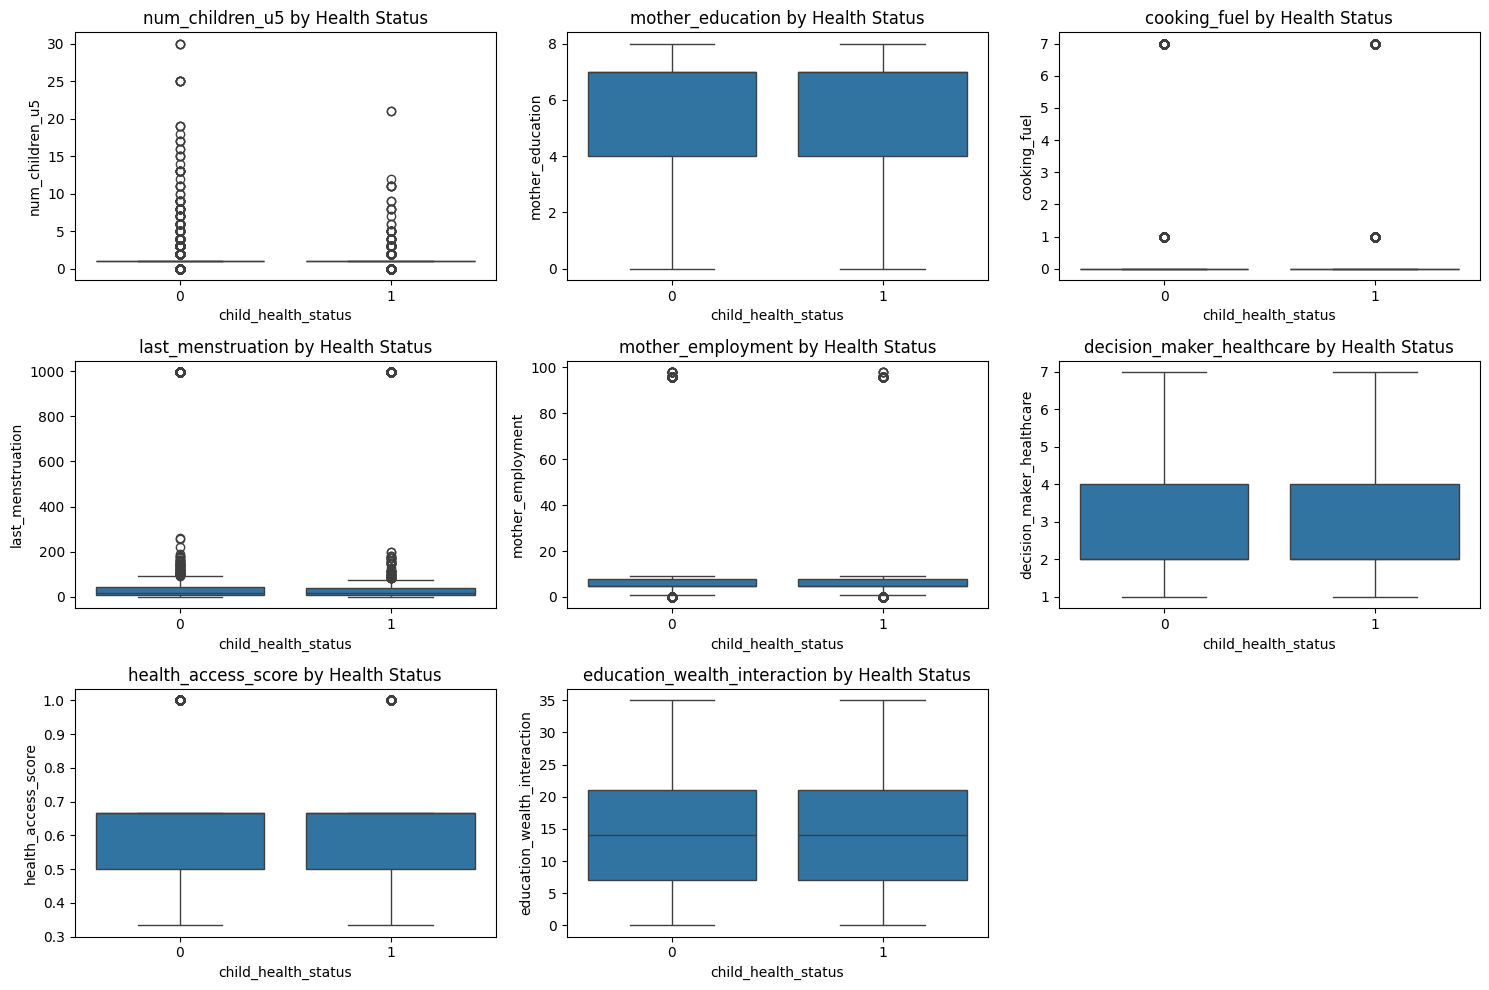

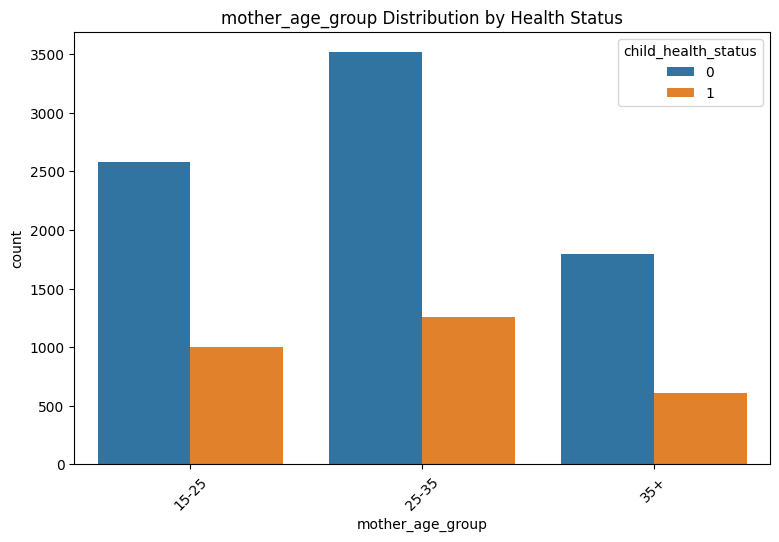

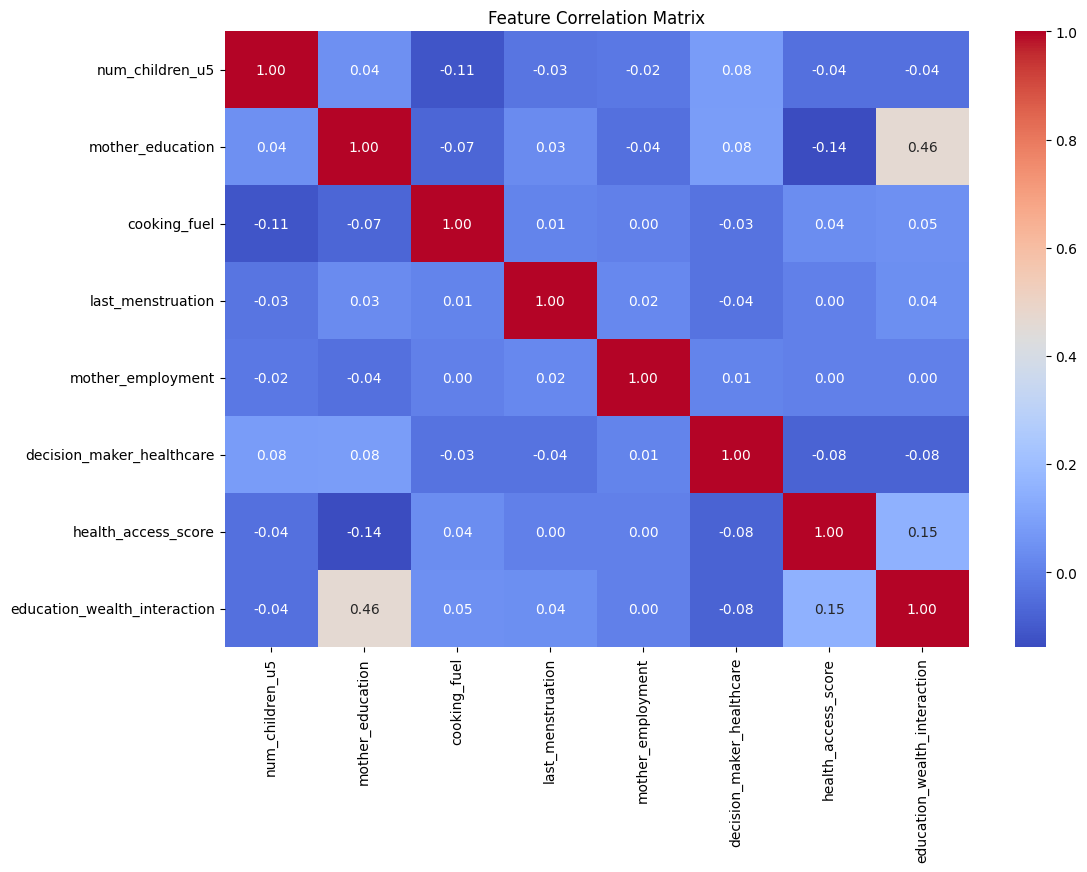

Selected Features:
['num_children_u5' 'mother_education' 'cooking_fuel' 'last_menstruation'
 'mother_employment' 'decision_maker_healthcare' 'health_access_score'
 'education_wealth_interaction' 'mother_age_group_15-25'
 'mother_age_group_25-35' 'mother_age_group_35+']
MODEL: Random Forest
Cross-validated F1: 0.615 ± 0.016
Test Accuracy: 0.824
Test F1: 0.672
Test ROC AUC: 0.850

Confusion Matrix:
[[1390  191]
 [ 188  388]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1581
           1       0.67      0.67      0.67       576

    accuracy                           0.82      2157
   macro avg       0.78      0.78      0.78      2157
weighted avg       0.82      0.82      0.82      2157

MODEL: XGBoost
Cross-validated F1: 0.426 ± 0.013
Test Accuracy: 0.733
Test F1: 0.412
Test ROC AUC: 0.734

Confusion Matrix:
[[1379  202]
 [ 374  202]]

Classification Report:
              precision    recall  f1-score   s

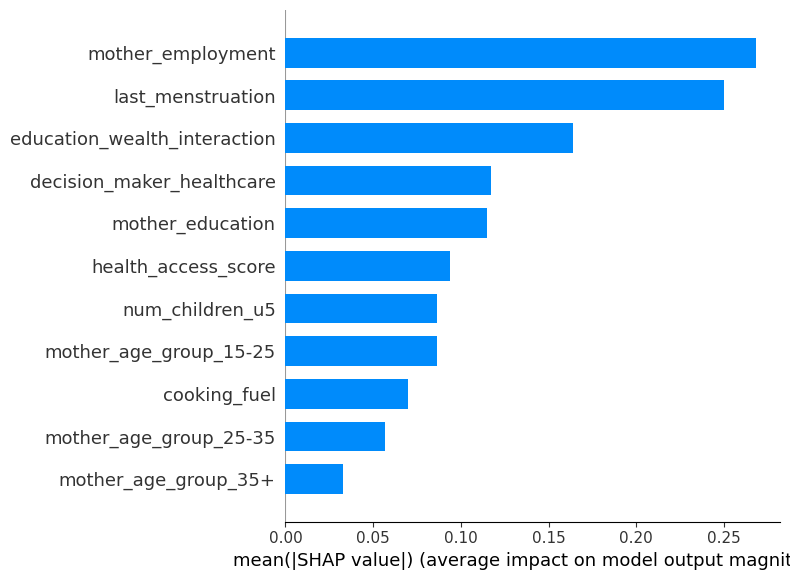

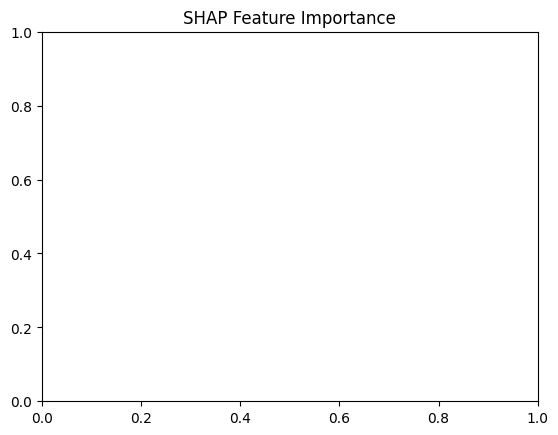

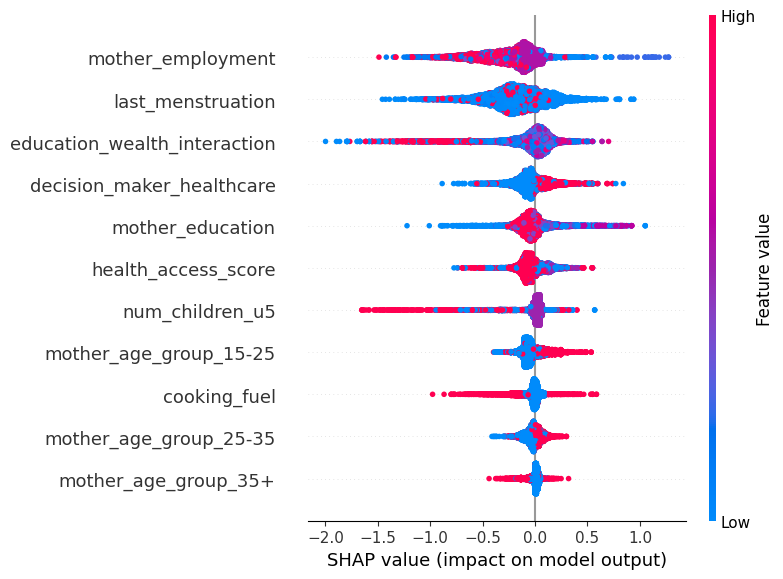

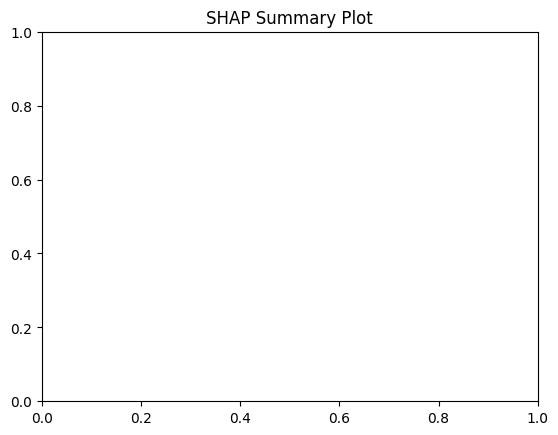

Geospatial map saved as 'health_status_map.html'


<IPython.core.display.Javascript object>

Final model pipeline created successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                            roc_auc_score, accuracy_score, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

# SHAP and Geospatial Libraries
import shap
import geopandas as gpd
import folium
from folium.plugins import HeatMap

# Dashboard Libraries
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# Set random seed for reproducibility
np.random.seed(42)

# 1. DATA LOADING AND INITIAL EXPLORATION
def load_data(filepath):
    """Load STATA file with proper error handling and memory optimization"""
    try:
        df = pd.read_stata(filepath, convert_categoricals=False)
        print("="*50)
        print("DATA LOADING SUMMARY")
        print("="*50)
        print(f"Dataset shape: {df.shape}")
        print("\nFirst 5 rows:")
        print(df.head())
        print("\nData types:")
        print(df.dtypes.value_counts())
        return df
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

df = load_data("/content/sample_data/TZKR82FL.DTA")
if df is None:
    raise ValueError("Data loading failed. Check file path or format.")

# 2. DATA CLEANING AND PREPROCESSING
def clean_data(df):
    """Comprehensive data cleaning function"""
    threshold = df.shape[0] * 0.7
    df = df.dropna(thresh=threshold, axis=1)

    features = {
        'v034': 'num_children_u5',
        'v107': 'mother_education',
        'v160': 'cooking_fuel',
        'v221': 'last_menstruation',
        'v190': 'wealth_index',
        'v138': 'num_people_in_household',
        'v012': 'mother_age',
        'v501': 'marital_status',
        'v705': 'mother_employment',
        'v025': 'residence',
        'v151': 'household_head_sex',
        'v157': 'media_exposure',
        'v467d': 'distance_to_health_facility',
        'v467f': 'time_to_health_facility',  # Corrected key typo
        'v743f': 'decision_maker_healthcare',
        'v731': 'husband_support_anc',
        'v367': 'child_health_status'
    }

    df = df[list(features.keys())].rename(columns=features)

    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[f'{col}_missing'] = df[col].isnull().astype(int)

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if col.endswith('_missing'): continue
        df[col].fillna(df[col].median(), inplace=True)

    for col in df.select_dtypes(include=['object', 'category']).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

    df['child_health_status'] = df['child_health_status'].map({1: 0, 2: 1, 3: 1})

    df['health_access_score'] = (df['distance_to_health_facility'] /
                                (df['time_to_health_facility'] + 1))
    df['mother_age_group'] = pd.cut(df['mother_age'],
                                   bins=[15, 25, 35, 49],
                                   labels=["15-25", "25-35", "35+"])
    df['education_wealth_interaction'] = df['mother_education'] * df['wealth_index']

    return df

df_clean = clean_data(df)

# 3. EXPLORATORY DATA ANALYSIS
def perform_eda(df):
    plt.figure(figsize=(10, 5))
    sns.countplot(x='child_health_status', data=df)
    plt.title('Distribution of Child Health Status')
    plt.show()

    num_cols = [c for c in df.select_dtypes(include=['float64', 'int64']).columns
                if c not in ['child_health_status'] and not c.endswith('_missing')]

    plt.figure(figsize=(15, 10))
    for i, col in enumerate(num_cols[:9]):
        plt.subplot(3, 3, i+1)
        sns.boxplot(x='child_health_status', y=col, data=df)
        plt.title(f'{col} by Health Status')
    plt.tight_layout()
    plt.show()

    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(cat_cols[:4]):
        plt.subplot(2, 2, i+1)
        sns.countplot(x=col, hue='child_health_status', data=df)
        plt.title(f'{col} Distribution by Health Status')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 8))
    corr_matrix = df[num_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Feature Correlation Matrix')
    plt.show()

perform_eda(df_clean)

# 4. FEATURE ENGINEERING AND SELECTION
def prepare_features(df):
    X = df.drop(columns=['child_health_status'])
    y = df['child_health_status']

    numeric_features = [c for c in X.select_dtypes(include=['float64', 'int64']).columns
                       if not c.endswith('_missing')]
    categorical_features = X.select_dtypes(include=['object', 'category']).columns

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)])

    feature_selector = SelectKBest(score_func=f_classif, k=15)

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selector', feature_selector)])

    X_processed = pipeline.fit_transform(X, y)

    numeric_features_processed = pipeline.named_steps['preprocessor'].\
        named_transformers_['num'].get_feature_names_out(numeric_features)
    categorical_features_processed = pipeline.named_steps['preprocessor'].\
        named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_features = np.concatenate([numeric_features_processed, categorical_features_processed])

    selected_features_mask = pipeline.named_steps['feature_selector'].get_support()
    selected_features = all_features[selected_features_mask]

    print("Selected Features:")
    print(selected_features)

    return X_processed, y, pipeline, selected_features

X_processed, y, preprocessing_pipeline, selected_features = prepare_features(df_clean)

# 5. MODEL BUILDING AND EVALUATION
def build_and_evaluate_models(X, y, preprocessor):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    models = {
        'Random Forest': ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', RandomForestClassifier(random_state=42))
        ]),
        'XGBoost': ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
        ]),
        'Gradient Boosting': ImbPipeline([ # Corrected indentation here
            ('smote', SMOTE(random_state=42)),
            ('classifier', GradientBoostingClassifier(random_state=42))
        ])
    }

    results = {}
    for name, model in models.items():
        # Preprocess data within the loop
        X_train_processed = preprocessor.fit_transform(X_train, y_train)
        X_test_processed = preprocessor.transform(X_test)

        cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='f1')
        model.fit(X_train_processed, y_train)  # Fit on processed data
        y_pred = model.predict(X_test_processed)  # Predict on processed data
        y_prob = model.predict_proba(X_test_processed)[:, 1]  # Predict probabilities


        results[name] = {
            'cv_mean_f1': cv_scores.mean(),
            'cv_std_f1': cv_scores.std(),
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_f1': f1_score(y_test, y_pred),
            'test_roc_auc': roc_auc_score(y_test, y_prob),
            'confusion_matrix': confusion_matrix(y_test, y_pred),
            'classification_report': classification_report(y_test, y_pred)
        }

        print("="*50)
        print(f"MODEL: {name}")
        print("="*50)
        print(f"Cross-validated F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        print(f"Test Accuracy: {results[name]['test_accuracy']:.3f}")
        print(f"Test F1: {results[name]['test_f1']:.3f}")
        print(f"Test ROC AUC: {results[name]['test_roc_auc']:.3f}")
        print("\nConfusion Matrix:")
        print(results[name]['confusion_matrix'])
        print("\nClassification Report:")
        print(results[name]['classification_report'])

    return results, models

results, models = build_and_evaluate_models(df_clean.drop(columns=['child_health_status']), y, preprocessing_pipeline)

# 6. MODEL OPTIMIZATION (Corrected Indentation)
def optimize_best_model(X, y, model_choice):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    numeric_features = [c for c in X.select_dtypes(include=['float64', 'int64']).columns
                       if not c.endswith('_missing')]
    categorical_features = X.select_dtypes(include=['object', 'category']).columns

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)])

    if model_choice == 'xgb':
        param_grid = {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5],
            'classifier__learning_rate': [0.01, 0.1]
        }
        model = XGBClassifier(random_state=42, eval_metric='logloss')
    elif model_choice == 'rf':
        param_grid = {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5, None]
        }
        model = RandomForestClassifier(random_state=42)
    elif model_choice == 'gb':
        param_grid = {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1]
        }
        model = GradientBoostingClassifier(random_state=42)
    else:
        raise ValueError("model_choice must be 'xgb', 'rf', or 'gb'")

    smote = SMOTE(random_state=42)
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', model)
    ])

    try:
        grid_search = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            scoring='f1',
            cv=5,
            n_jobs=-1,
            verbose=1
        )

        print("Starting grid search...")
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)

        print("\nOptimized Model Performance:")
        print(f"Best params: {grid_search.best_params_}")
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
        print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")

        return best_model
    except Exception as e:
        print(f"Error during grid search: {str(e)}")
        print("Trying fallback method...")
        pipeline.fit(X_train, y_train)
        return pipeline

best_model = optimize_best_model(df_clean.drop(columns=['child_health_status']), y, model_choice='xgb')

# 7. SHAP MODEL INTERPRETABILITY
def shap_analysis(model, X, feature_names):
    # Get the preprocessed data using the pipeline's preprocessor
    X_processed = model.named_steps['preprocessor'].transform(X)

    # Get the original feature names before one-hot encoding
    original_feature_names = list(X.columns)

    # Get the feature names after preprocessing (including one-hot encoded)
    encoded_feature_names = model.named_steps['preprocessor'].get_feature_names_out(original_feature_names)

    # Use the encoded feature names for the SHAP analysis
    explainer = shap.TreeExplainer(model.named_steps['classifier'])
    shap_values = explainer.shap_values(X_processed)

    # Use shap_values instead of shap_values[1]
    # shap_values provides SHAP values for all instances and features, which is what summary_plot expects
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_processed, feature_names=feature_names, plot_type="bar")
    plt.title("SHAP Feature Importance")
    plt.show()

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_processed, feature_names=feature_names)
    plt.title("SHAP Summary Plot")
    plt.show()

shap_analysis(best_model, df_clean.drop(columns=['child_health_status']), selected_features)

# 8. GEOSPATIAL ANALYSIS (Assuming DHS has region data)
def geospatial_analysis(df):
    # Mock geospatial data (replace with actual coordinates or region data from DHS)
    regions = df['residence'].value_counts().index
    # Added more mock coordinates to cover potential values in 'residence'
    mock_coords = {
        'urban': (-6.7924, 39.2083),  # Dar es Salaam
        'rural': (-8.9147, 33.4507),   # Mbeya (example rural)
        1: (-6.7924, 39.2083),  # Assume 1 represents urban for this example
        2: (-8.9147, 33.4507)   # Assume 2 represents rural for this example
    }

    gdf = gpd.GeoDataFrame(
        df.groupby('residence').agg({'child_health_status': 'mean'}).reset_index(),
        geometry=[gpd.points_from_xy([mock_coords.get(r, (0, 0))[1]], [mock_coords.get(r, (0, 0))[0]])[0]
                  for r in df['residence'].value_counts().index]
    )

    # Extract latitude and longitude from the 'geometry' column
    gdf['geometry.x'] = gdf['geometry'].apply(lambda point: point.x)
    gdf['geometry.y'] = gdf['geometry'].apply(lambda point: point.y)

    m = folium.Map(location=[-6.7924, 39.2083], zoom_start=6)
    HeatMap(data=gdf[['geometry.y', 'geometry.x', 'child_health_status']].values.tolist(),
            radius=15).add_to(m)

    m.save("health_status_map.html")
    print("Geospatial map saved as 'health_status_map.html'")

geospatial_analysis(df_clean)

# 9. INTERACTIVE DASHBOARD
app = Dash(__name__)

# Prepare SHAP values once (outside callback for efficiency)
X_processed = best_model.named_steps['preprocessor'].transform(df_clean.drop(columns=['child_health_status']))
explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
shap_values = explainer.shap_values(X_processed)

# Ensure SHAP values are in the expected format
if isinstance(shap_values, list):  # For multiclass models, shap_values is a list
    shap_values = shap_values[1]  # Use class 1 (incomplete immunization) for binary case

app.layout = html.Div([
    html.H1("Child Health Analysis Dashboard"),
    dcc.Graph(id='health-status-dist'),
    dcc.Graph(id='shap-plot'),
    dcc.Dropdown(
        id='feature-dropdown',
        options=[{'label': f, 'value': f} for f in selected_features],
        value=selected_features[0]
    ),
    dcc.Graph(id='feature-effect')
])

@app.callback(
    [Output('health-status-dist', 'figure'),
     Output('shap-plot', 'figure'),
     Output('feature-effect', 'figure')],
    [Input('feature-dropdown', 'value')]
)
def update_dashboard(selected_feature):
    # Health Status Distribution
    fig1 = px.histogram(df_clean, x='child_health_status',
                        title="Health Status Distribution",
                        labels={'child_health_status': 'Health Status (0=Complete, 1=Incomplete)'},
                        color_discrete_sequence=['#1f77b4'])

    # SHAP Bar Plot (mean absolute SHAP values for all features)
    mean_shap_values = np.abs(shap_values).mean(axis=0)  # Use absolute values for importance
    fig2 = px.bar(x=selected_features, y=mean_shap_values,
                  title="SHAP Feature Importance",
                  labels={'x': 'Features', 'y': 'Mean |SHAP Value|'},
                  color_discrete_sequence=['#ff7f0e'])

    # Feature Effect Plot (match selected_feature to original data)
    # Handle encoded features (e.g., from OneHotEncoder)
    if selected_feature in df_clean.columns:  # If feature is in original data
        x_values = df_clean[selected_feature]
    else:  # If feature is encoded (e.g., 'marital_status_1'), approximate with a related raw feature
        base_feature = selected_feature.split('_')[0]  # Extract base feature name
        if base_feature in df_clean.columns:
            x_values = df_clean[base_feature]
        else:
            x_values = np.zeros(len(df_clean))  # Fallback if no match

    feature_idx = list(selected_features).index(selected_feature)
    fig3 = px.scatter(x=x_values, y=shap_values[:, feature_idx],
                      title=f"SHAP Values for {selected_feature}",
                      labels={'x': selected_feature, 'y': 'SHAP Value'},
                      color_discrete_sequence=['#2ca02c'])

    return fig1, fig2, fig3

if __name__ == '__main__':
    # For Jupyter/Colab, use this instead of app.run_server(debug=True)
    app.run(mode='inline', debug=True)  # 'inline' for Jupyter/Colab compatibility


# 10. FINAL DEPLOYMENT PREPARATION
def create_deployment_pipeline():
    numeric_features = [c for c in df_clean.select_dtypes(include=['float64', 'int64']).columns
                       if c != 'child_health_status' and not c.endswith('_missing')]
    categorical_features = df_clean.select_dtypes(include=['object', 'category']).columns

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)])

    final_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', best_model.named_steps['classifier'])
    ])

    final_pipeline.fit(df_clean.drop(columns=['child_health_status']), df_clean['child_health_status'])
    return final_pipeline

final_pipeline = create_deployment_pipeline()
print("Final model pipeline created successfully!")

# New Section